In [1]:
# ============================================================
# CELL 1: SETUP + LOAD DATA
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from pathlib import Path

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR = Path.cwd().parent

TRAIN_PATH = BASE_DIR/"data/fraudTrain.csv"
TEST_PATH = BASE_DIR/"data/fraudTest.csv"

# from fraud_detect.inference.fraud_predict import predict_fraud

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain fraud distribution:")
print(train_df["is_fraud"].value_counts())

print("\nTrain fraud rate:")
print(f"{train_df['is_fraud'].mean() * 100:.4f}%")

print("\nTest fraud rate:")
print(f"{test_df['is_fraud'].mean() * 100:.4f}%")

print("\nColumns:")
print(train_df.columns.tolist())

DATASET INFORMATION
Train shape: (1296675, 23)
Test shape : (555719, 23)

Train fraud distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Train fraud rate:
0.5789%

Test fraud rate:
0.3860%

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [2]:
# ============================================================
# CELL 1: SETUP + LOAD DATA
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from pathlib import Path


# ============================================================
# SETTINGS
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR = Path.cwd().parent

TRAIN_PATH = BASE_DIR / "data/fraudTrain.csv"
TEST_PATH = BASE_DIR / "data/fraudTest.csv"


# ============================================================
# LOAD DATA
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain fraud distribution:")
print(train_df["is_fraud"].value_counts())

print("\nTrain fraud rate:")
print(f"{train_df['is_fraud'].mean() * 100:.4f}%")

print("\nTest fraud rate:")
print(f"{test_df['is_fraud'].mean() * 100:.4f}%")

print("\nColumns:")
print(train_df.columns.tolist())


# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

# Convert timestamps
train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

test_df["trans_date_trans_time"] = pd.to_datetime(
    test_df["trans_date_trans_time"]
)


# ------------------------------------------------------------
# SORT TRAINING DATA CHRONOLOGICALLY
# ------------------------------------------------------------

train_df = train_df.sort_values(
    "trans_date_trans_time"
).reset_index(drop=True)


# ------------------------------------------------------------
# 80% TRAIN / 20% VALIDATION
# ------------------------------------------------------------

split_idx = int(len(train_df) * 0.80)

train_part = train_df.iloc[:split_idx].copy()

val_part = train_df.iloc[split_idx:].copy()


# ============================================================
# CHECK SPLIT
# ============================================================

print("\n" + "=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("Training shape   :", train_part.shape)
print("Validation shape :", val_part.shape)
print("Test shape       :", test_df.shape)


print("\nTraining time range:")
print(
    train_part["trans_date_trans_time"].min(),
    "→",
    train_part["trans_date_trans_time"].max()
)

print("\nValidation time range:")
print(
    val_part["trans_date_trans_time"].min(),
    "→",
    val_part["trans_date_trans_time"].max()
)

print("\nTest time range:")
print(
    test_df["trans_date_trans_time"].min(),
    "→",
    test_df["trans_date_trans_time"].max()
)


print("\nTraining fraud rate:")
print(f"{train_part['is_fraud'].mean() * 100:.4f}%")

print("\nValidation fraud rate:")
print(f"{val_part['is_fraud'].mean() * 100:.4f}%")

print("\nTest fraud rate:")
print(f"{test_df['is_fraud'].mean() * 100:.4f}%")

DATASET INFORMATION
Train shape: (1296675, 23)
Test shape : (555719, 23)

Train fraud distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Train fraud rate:
0.5789%

Test fraud rate:
0.3860%

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

TRAIN / VALIDATION SPLIT
Training shape   : (1037340, 23)
Validation shape : (259335, 23)
Test shape       : (555719, 23)

Training time range:
2019-01-01 00:00:18 → 2020-03-06 07:15:17

Validation time range:
2020-03-06 07:16:43 → 2020-06-21 12:13:37

Test time range:
2020-06-21 12:14:25 → 2020-12-31 23:59:34

Training fraud rate:
0.5753%

Validation fraud rate:
0.5931%

Test fraud rate:
0.3860%


In [3]:
# ============================================================
# CELL 2: MEMORY-EFFICIENT FEATURE ENGINEERING
# ============================================================

def haversine_distance(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def basic_features(df):

    df = df.copy()

    # --------------------------------------------------------
    # DATETIME
    # --------------------------------------------------------

    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"]
    )

    df["trans_hour"] = (
        df["trans_date_trans_time"].dt.hour
    )

    df["trans_day"] = (
        df["trans_date_trans_time"].dt.day
    )

    df["trans_month"] = (
        df["trans_date_trans_time"].dt.month
    )

    df["trans_dayofweek"] = (
        df["trans_date_trans_time"].dt.dayofweek
    )

    df["trans_dayofyear"] = (
        df["trans_date_trans_time"].dt.dayofyear
    )

    df["is_weekend"] = (
        df["trans_dayofweek"] >= 5
    ).astype("int8")

    df["is_night"] = (
        (df["trans_hour"] < 6)
        |
        (df["trans_hour"] >= 22)
    ).astype("int8")

    # --------------------------------------------------------
    # AGE
    # --------------------------------------------------------

    df["dob"] = pd.to_datetime(df["dob"])

    df["customer_age"] = (
        df["trans_date_trans_time"] - df["dob"]
    ).dt.days / 365.25

    # --------------------------------------------------------
    # DISTANCE
    # --------------------------------------------------------

    df["distance_km"] = haversine_distance(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

    # --------------------------------------------------------
    # AMOUNT
    # --------------------------------------------------------

    df["log_amount"] = np.log1p(
        df["amt"]
    )

    return df


# ============================================================
# CREATE RAW FEATURE DATA
# ============================================================

train_features = basic_features(
    train_part
)

val_features = basic_features(
    val_part
)

test_features = basic_features(
    test_df
)


# ============================================================
# CARD BEHAVIOR FEATURES
# ============================================================

# IMPORTANT:
# Calculate statistics from TRAINING data only.
# This prevents validation/test information leaking backward.

card_stats = (
    train_features
    .groupby("cc_num")
    .agg(
        card_transaction_count=(
            "cc_num",
            "size"
        ),

        card_avg_amount=(
            "amt",
            "mean"
        ),

        card_amount_std=(
            "amt",
            "std"
        ),

        card_max_amount=(
            "amt",
            "max"
        ),

        card_unique_merchants=(
            "merchant",
            "nunique"
        ),

        card_unique_cities=(
            "city",
            "nunique"
        )
    )
)


# Fill standard deviation
card_stats["card_amount_std"] = (
    card_stats["card_amount_std"]
    .fillna(0)
)


# ============================================================
# MERCHANT FREQUENCY
# ============================================================

merchant_frequency = (
    train_features["merchant"]
    .value_counts(
        normalize=True
    )
)


# ============================================================
# CITY FREQUENCY
# ============================================================

city_frequency = (
    train_features["city"]
    .value_counts(
        normalize=True
    )
)


# ============================================================
# APPLY BEHAVIOR FEATURES
# ============================================================

def apply_behavior_features(
    df,
    card_stats,
    merchant_frequency,
    city_frequency
):

    df = df.copy()

    # Card statistics
    df = df.join(
        card_stats,
        on="cc_num"
    )

    # Merchant frequency
    df["merchant_frequency"] = (
        df["merchant"]
        .map(merchant_frequency)
        .fillna(0)
    )

    # City frequency
    df["city_frequency"] = (
        df["city"]
        .map(city_frequency)
        .fillna(0)
    )

    # --------------------------------------------------------
    # DROP HIGH-CARDINALITY RAW IDENTIFIERS
    # --------------------------------------------------------

    drop_cols = [
        "is_fraud",
        "trans_num",
        "trans_date_trans_time",
        "dob",
        "first",
        "last",
        "street",
        "cc_num"
    ]

    drop_cols = [
        c for c in drop_cols
        if c in df.columns
    ]

    df = df.drop(
        columns=drop_cols
    )

    return df


X_train = apply_behavior_features(
    train_features,
    card_stats,
    merchant_frequency,
    city_frequency
)

X_val = apply_behavior_features(
    val_features,
    card_stats,
    merchant_frequency,
    city_frequency
)

X_test = apply_behavior_features(
    test_features,
    card_stats,
    merchant_frequency,
    city_frequency
)

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

FEATURE ENGINEERING COMPLETE
Training: (1037340, 33)
Validation: (259335, 33)
Test: (555719, 33)

Features:
['Unnamed: 0', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'trans_dayofweek', 'trans_dayofyear', 'is_weekend', 'is_night', 'customer_age', 'distance_km', 'log_amount', 'card_transaction_count', 'card_avg_amount', 'card_amount_std', 'card_max_amount', 'card_unique_merchants', 'card_unique_cities', 'merchant_frequency', 'city_frequency']


In [4]:
# ============================================================
# CELL 3: CLEAN + ENCODE
# ============================================================

y_train = train_part["is_fraud"].astype(np.int8)

y_val = val_part["is_fraud"].astype(np.int8)

y_test = test_df["is_fraud"].astype(np.int8)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

def clean_feature_names(df):

    df = df.copy()

    new_columns = []

    for col in df.columns:

        col = str(col)

        col = re.sub(
            r"[^A-Za-z0-9_]",
            "_",
            col
        )

        col = re.sub(
            r"_+",
            "_",
            col
        )

        col = col.strip("_")

        new_columns.append(col)

    df.columns = new_columns

    return df


X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)
X_test = clean_feature_names(X_test)

# Same column order
X_val = X_val[
    X_train.columns
]

X_test = X_test[
    X_train.columns
]


# ============================================================
# CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "merchant",
    "category",
    "gender",
    "city",
    "state",
    "job"
]

categorical_features = [
    c for c in categorical_features
    if c in X_train.columns
]

print("Categorical features:")
print(categorical_features)


# ============================================================
# LIGHTGBM / CATBOOST DATA
# ============================================================

for col in categorical_features:

    X_train[col] = (
        X_train[col]
        .astype("category")
    )

    # Use same category levels
    categories = (
        X_train[col]
        .cat.categories
    )

    X_val[col] = pd.Categorical(
        X_val[col],
        categories=categories
    )

    X_test[col] = pd.Categorical(
        X_test[col],
        categories=categories
    )


# ============================================================
# NUMERICAL ENCODING
# For Logistic Regression / RF / XGBoost / NN
# ============================================================

X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()


# Encode categorical columns using category codes
for col in categorical_features:

    mapping = {
        category: i
        for i, category in enumerate(
            X_train[col].cat.categories
        )
    }

    X_train_encoded[col] = (
        X_train_encoded[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(np.float32)
    )

    X_val_encoded[col] = (
        X_val_encoded[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(np.float32)
    )

    X_test_encoded[col] = (
        X_test_encoded[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(np.float32)
    )


# ============================================================
# CONVERT NUMERICAL FEATURES
# ============================================================

for col in X_train_encoded.columns:

    if col not in categorical_features:

        X_train_encoded[col] = pd.to_numeric(
            X_train_encoded[col],
            errors="coerce"
        ).astype(np.float32)

        X_val_encoded[col] = pd.to_numeric(
            X_val_encoded[col],
            errors="coerce"
        ).astype(np.float32)

        X_test_encoded[col] = pd.to_numeric(
            X_test_encoded[col],
            errors="coerce"
        ).astype(np.float32)


# ============================================================
# REPLACE INF / NaN
# ============================================================

X_train_encoded = (
    X_train_encoded
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

X_val_encoded = (
    X_val_encoded
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

X_test_encoded = (
    X_test_encoded
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

train_medians = (
    X_train_encoded
    .median(numeric_only=True)
)

X_train_encoded = (
    X_train_encoded
    .fillna(train_medians)
)

X_val_encoded = (
    X_val_encoded
    .fillna(train_medians)
)

X_test_encoded = (
    X_test_encoded
    .fillna(train_medians)
)


# ============================================================
# SCALE
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_encoded
).astype(np.float32)

X_val_scaled = scaler.transform(
    X_val_encoded
).astype(np.float32)

X_test_scaled = scaler.transform(
    X_test_encoded
).astype(np.float32)


# ============================================================
# CLASS WEIGHT
# ============================================================

negative = (
    y_train == 0
).sum()

positive = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative / positive
)


print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

print(
    "Features:",
    X_train_encoded.shape[1]
)

print(
    "Training rows:",
    X_train_encoded.shape[0]
)

print(
    "Scale pos weight:",
    scale_pos_weight
)

print(
    "Memory:",
    round(
        X_train_encoded.memory_usage(
            deep=True
        ).sum() / 1024**2,
        2
    ),
    "MB"
)

y_train: (1037340,)
y_val  : (259335,)
y_test : (555719,)

Training target distribution:
is_fraud
0    1031372
1       5968
Name: count, dtype: int64

Validation target distribution:
is_fraud
0    257797
1      1538
Name: count, dtype: int64

Test target distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64
Categorical features:
['merchant', 'category', 'gender', 'city', 'state', 'job']
PREPROCESSING COMPLETE
Features: 33
Training rows: 1037340
Scale pos weight: 172.8170241286863
Memory: 130.59 MB


In [5]:
# ============================================================
# CELL 4: EVALUATION FUNCTIONS
# ============================================================

def find_best_threshold(
    y_true,
    probabilities
):

    thresholds = np.arange(
        0.01,
        0.96,
        0.01
    )

    results = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        results.append({

            "Threshold": threshold,

            "Precision": precision,

            "Recall": recall,

            "F1": f1,

            "Fraud Alerts": predictions.sum()
        })

    results_df = pd.DataFrame(results)

    best = results_df.loc[
        results_df["F1"].idxmax()
    ]

    return best, results_df


def validation_metrics(
    model_name,
    y_true,
    probabilities,
    threshold
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    return {

        "Model": model_name,

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        ),

        "PR-AUC": average_precision_score(
            y_true,
            probabilities
        ),

        "Threshold": threshold,

        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Fraud Alerts": predictions.sum()
    }


model_probabilities = {}
model_thresholds = {}
threshold_tables = {}

In [6]:
# ============================================================
# CELL 5: LOGISTIC REGRESSION + RANDOM FOREST
# ============================================================

# ============================================================
# LOGISTIC REGRESSION
# ============================================================

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_val_prob = lr_model.predict_proba(
    X_val_scaled
)[:, 1]

lr_best, lr_threshold_table = (
    find_best_threshold(
        y_val,
        lr_val_prob
    )
)

model_probabilities[
    "Logistic Regression"
] = lr_val_prob

model_thresholds[
    "Logistic Regression"
] = lr_best["Threshold"]

threshold_tables[
    "Logistic Regression"
] = lr_threshold_table

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        lr_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        lr_val_prob
    )
)

print(
    "Best threshold:",
    lr_best["Threshold"]
)

print(
    "Best F1:",
    lr_best["F1"]
)


# ============================================================
# RANDOM FOREST
# ============================================================

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=250,

    max_depth=18,

    min_samples_leaf=10,

    max_features="sqrt",

    class_weight="balanced_subsample",

    random_state=42,

    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

rf_val_prob = rf_model.predict_proba(
    X_val_encoded
)[:, 1]

rf_best, rf_threshold_table = (
    find_best_threshold(
        y_val,
        rf_val_prob
    )
)

model_probabilities[
    "Random Forest"
] = rf_val_prob

model_thresholds[
    "Random Forest"
] = rf_best["Threshold"]

threshold_tables[
    "Random Forest"
] = rf_threshold_table

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        rf_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        rf_val_prob
    )
)

print(
    "Best threshold:",
    rf_best["Threshold"]
)

print(
    "Best F1:",
    rf_best["F1"]
)

LOGISTIC REGRESSION
ROC-AUC: 0.9431870424675077
PR-AUC: 0.24998073401382798
Best threshold: 0.9500000000000001
Best F1: 0.4219977553310887

RANDOM FOREST
ROC-AUC: 0.9928933798895898
PR-AUC: 0.7994988123041881
Best threshold: 0.51
Best F1: 0.7661895023858214


In [ ]:
# ============================================================
# CELL 6: XGBOOST + LIGHTGBM + CATBOOST
# ============================================================

# ============================================================
# XGBOOST
# ============================================================

print("=" * 60)
print("XGBOOST")
print("=" * 60)

xgb_model = XGBClassifier(

    objective="binary:logistic",

    n_estimators=1000,

    learning_rate=0.03,

    max_depth=8,

    min_child_weight=10,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.1,

    reg_lambda=2.0,

    scale_pos_weight=scale_pos_weight,

    eval_metric="aucpr",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)

xgb_model.fit(

    X_train_encoded,

    y_train,

    eval_set=[
        (
            X_val_encoded,
            y_val
        )
    ],

    verbose=100
)

xgb_val_prob = xgb_model.predict_proba(
    X_val_encoded
)[:, 1]

xgb_best, xgb_threshold_table = (
    find_best_threshold(
        y_val,
        xgb_val_prob
    )
)

model_probabilities[
    "XGBoost"
] = xgb_val_prob

model_thresholds[
    "XGBoost"
] = xgb_best["Threshold"]

threshold_tables[
    "XGBoost"
] = xgb_threshold_table

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        xgb_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        xgb_val_prob
    )
)

print(
    "Best threshold:",
    xgb_best["Threshold"]
)

print(
    "Best F1:",
    xgb_best["F1"]
)


# ============================================================
# LIGHTGBM
# ============================================================

print("\n" + "=" * 60)
print("LIGHTGBM")
print("=" * 60)

lgb_model = LGBMClassifier(

    objective="binary",

    n_estimators=1200,

    learning_rate=0.03,

    num_leaves=64,

    max_depth=-1,

    min_child_samples=100,

    subsample=0.8,

    subsample_freq=1,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=2.0,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    n_jobs=-1,

    verbosity=-1
)

lgb_model.fit(

    X_train,

    y_train,

    categorical_feature=categorical_features,

    eval_set=[
        (
            X_val,
            y_val
        )
    ]
)

lgb_val_prob = lgb_model.predict_proba(
    X_val
)[:, 1]

lgb_best, lgb_threshold_table = (
    find_best_threshold(
        y_val,
        lgb_val_prob
    )
)

model_probabilities[
    "LightGBM"
] = lgb_val_prob

model_thresholds[
    "LightGBM"
] = lgb_best["Threshold"]

threshold_tables[
    "LightGBM"
] = lgb_threshold_table

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        lgb_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        lgb_val_prob
    )
)

print(
    "Best threshold:",
    lgb_best["Threshold"]
)

print(
    "Best F1:",
    lgb_best["F1"]
)


# ============================================================
# CATBOOST
# ============================================================

print("\n" + "=" * 60)
print("CATBOOST")
print("=" * 60)

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in categorical_features:

    X_train_cb[col] = (
        X_train_cb[col]
        .astype(str)
    )

    X_val_cb[col] = (
        X_val_cb[col]
        .astype(str)
    )

    X_test_cb[col] = (
        X_test_cb[col]
        .astype(str)
    )

cat_indices = [
    X_train_cb.columns.get_loc(col)
    for col in categorical_features
]

cat_model = CatBoostClassifier(

    loss_function="Logloss",

    eval_metric="PRAUC",

    iterations=1200,

    learning_rate=0.05,

    depth=8,

    l2_leaf_reg=5,

    auto_class_weights="Balanced",

    random_seed=42,

    thread_count=-1,

    verbose=100
)



XGBOOST
[0]	validation_0-aucpr:0.75809
[100]	validation_0-aucpr:0.84490
[200]	validation_0-aucpr:0.87167
[300]	validation_0-aucpr:0.85792
[400]	validation_0-aucpr:0.85807
[500]	validation_0-aucpr:0.85880
[600]	validation_0-aucpr:0.85974
[700]	validation_0-aucpr:0.86329
[800]	validation_0-aucpr:0.86460
[900]	validation_0-aucpr:0.86648
[999]	validation_0-aucpr:0.86721
ROC-AUC: 0.99651059227744
PR-AUC: 0.8672296947248361
Best threshold: 0.66
Best F1: 0.8096935138987883

LIGHTGBM
ROC-AUC: 0.9819732608533788
PR-AUC: 0.7974517012044806
Best threshold: 0.19
Best F1: 0.7625847911460193

CATBOOST


CatBoostError: Invalid type for cat_feature[non-default value idx=3715,feature_idx=5]=nan : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [8]:
# ============================================================
# CLEAN CATEGORICAL VALUES FOR CATBOOST
# ============================================================

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in categorical_features:

    X_train_cb[col] = (
        X_train_cb[col]
        .astype("string")
        .fillna("__MISSING__")
    )

    X_val_cb[col] = (
        X_val_cb[col]
        .astype("string")
        .fillna("__MISSING__")
    )

    X_test_cb[col] = (
        X_test_cb[col]
        .astype("string")
        .fillna("__MISSING__")
    )

print("CatBoost categorical NaNs:")
print(X_train_cb[categorical_features].isna().sum())

cat_model.fit(

    X_train_cb,

    y_train,

    cat_features=cat_indices,

    eval_set=(
        X_val_cb,
        y_val
    ),

    early_stopping_rounds=100
)

cat_val_prob = cat_model.predict_proba(
    X_val_cb
)[:, 1]

cat_best, cat_threshold_table = (
    find_best_threshold(
        y_val,
        cat_val_prob
    )
)

model_probabilities[
    "CatBoost"
] = cat_val_prob

model_thresholds[
    "CatBoost"
] = cat_best["Threshold"]

threshold_tables[
    "CatBoost"
] = cat_threshold_table

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        cat_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        cat_val_prob
    )
)

print(
    "Best threshold:",
    cat_best["Threshold"]
)

print(
    "Best F1:",
    cat_best["F1"]
)

CatBoost categorical NaNs:
merchant    0
category    0
gender      0
city        0
state       0
job         0
dtype: int64
0:	learn: 0.9813314	test: 0.9817747	best: 0.9817747 (0)	total: 670ms	remaining: 13m 23s
100:	learn: 0.9986504	test: 0.9965028	best: 0.9965028 (100)	total: 50.3s	remaining: 9m 6s
200:	learn: 0.9995650	test: 0.9965326	best: 0.9967405 (181)	total: 1m 38s	remaining: 8m 7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9967405169
bestIteration = 181

Shrink model to first 182 iterations.
ROC-AUC: 0.9966675400433136
PR-AUC: 0.8439856577166943
Best threshold: 0.91
Best F1: 0.7891202149093351


In [9]:
# ============================================================
# CELL 7: NEURAL NETWORK
# ============================================================

print("=" * 60)
print("NEURAL NETWORK")
print("=" * 60)

tf.random.set_seed(42)
np.random.seed(42)

nn_model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(
            X_train_scaled.shape[1],
        )
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        1,
        activation="sigmoid"
    )
])

nn_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[

        tf.keras.metrics.AUC(
            name="roc_auc"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

nn_class_weights = {
    0: 1.0,
    1: scale_pos_weight
}

early_stopping = EarlyStopping(

    monitor="val_pr_auc",

    mode="max",

    patience=6,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_pr_auc",

    mode="max",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    verbose=1
)

history = nn_model.fit(

    X_train_scaled,

    y_train.values,

    validation_data=(
        X_val_scaled,
        y_val.values
    ),

    epochs=30,

    batch_size=4096,

    class_weight=nn_class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

nn_val_prob = nn_model.predict(
    X_val_scaled,
    batch_size=8192,
    verbose=0
).ravel()

nn_best, nn_threshold_table = (
    find_best_threshold(
        y_val,
        nn_val_prob
    )
)

model_probabilities[
    "Neural Network"
] = nn_val_prob

model_thresholds[
    "Neural Network"
] = nn_best["Threshold"]

threshold_tables[
    "Neural Network"
] = nn_threshold_table

print("\nNeural Network Results")

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        nn_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        nn_val_prob
    )
)

print(
    "Best threshold:",
    nn_best["Threshold"]
)

print(
    "Best F1:",
    nn_best["F1"]
)

NEURAL NETWORK
Epoch 1/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8007 - pr_auc: 0.2253 - precision: 0.0259 - recall: 0.8076 - roc_auc: 0.8973 - val_loss: 0.2590 - val_pr_auc: 0.2957 - val_precision: 0.0591 - val_recall: 0.7958 - val_roc_auc: 0.9411 - learning_rate: 0.0010
Epoch 2/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5961 - pr_auc: 0.2966 - precision: 0.0420 - recall: 0.8582 - roc_auc: 0.9454 - val_loss: 0.2459 - val_pr_auc: 0.3365 - val_precision: 0.0541 - val_recall: 0.8791 - val_roc_auc: 0.9551 - learning_rate: 0.0010
Epoch 3/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5251 - pr_auc: 0.3343 - precision: 0.0510 - recall: 0.8797 - roc_auc: 0.9576 - val_loss: 0.2146 - val_pr_auc: 0.3597 - val_precision: 0.0652 - val_recall: 0.8940 - val_roc_auc: 0.9643 - learning_rate: 0.0010
Epoch 4/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4587 - pr_auc: 0.3691 - precision: 0.0601 - recall: 0.9005 - roc_auc: 0.9670 - val_loss: 0.1694 - val_pr_auc: 0.4

VALIDATION MODEL COMPARISON
              Model  ROC-AUC   PR-AUC  Threshold  Precision   Recall       F1  Fraud Alerts
            XGBoost 0.996511 0.867230       0.66   0.895899 0.738622 0.809694          1268
           CatBoost 0.996668 0.843986       0.91   0.815972 0.763979 0.789120          1440
      Random Forest 0.992893 0.799499       0.51   0.805158 0.730819 0.766190          1396
           LightGBM 0.981973 0.797452       0.19   0.845606 0.694408 0.762585          1263
     Neural Network 0.991530 0.729702       0.95   0.596535 0.783485 0.677347          2020
Logistic Regression 0.943187 0.249981       0.95   0.371175 0.488947 0.421998          2026

SELECTED MODEL: XGBoost
SELECTED THRESHOLD: 0.66

FINAL TEST RESULTS
Model        : XGBoost
Threshold    : 0.66
Accuracy     : 0.9985
Precision    : 0.8925
Recall       : 0.6848
F1           : 0.7750
ROC-AUC      : 0.9929
PR-AUC       : 0.8180
Fraud Alerts : 1646
Actual Fraud : 2145

Confusion Matrix:
[[553397    177]
 [   67

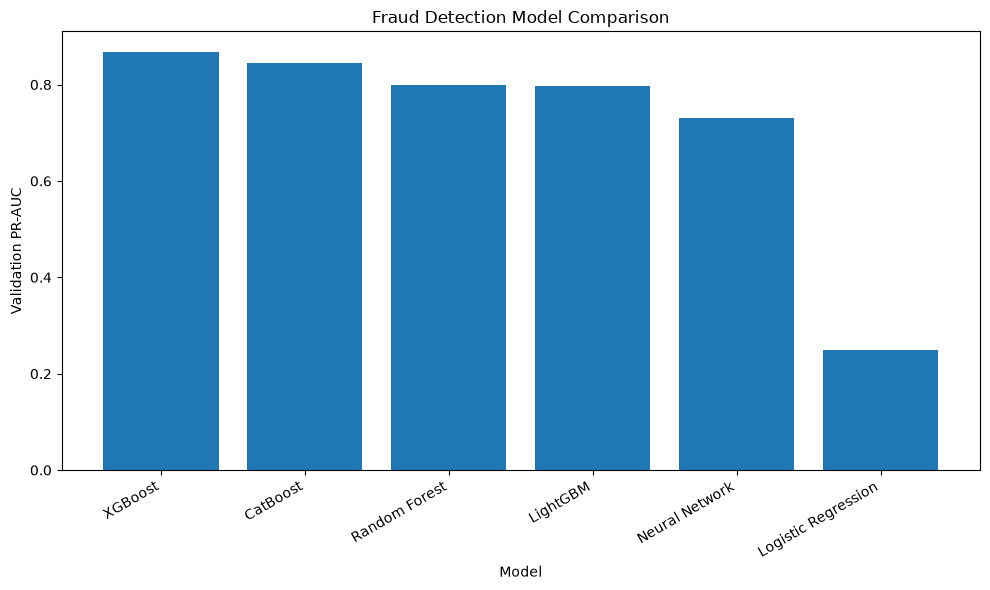

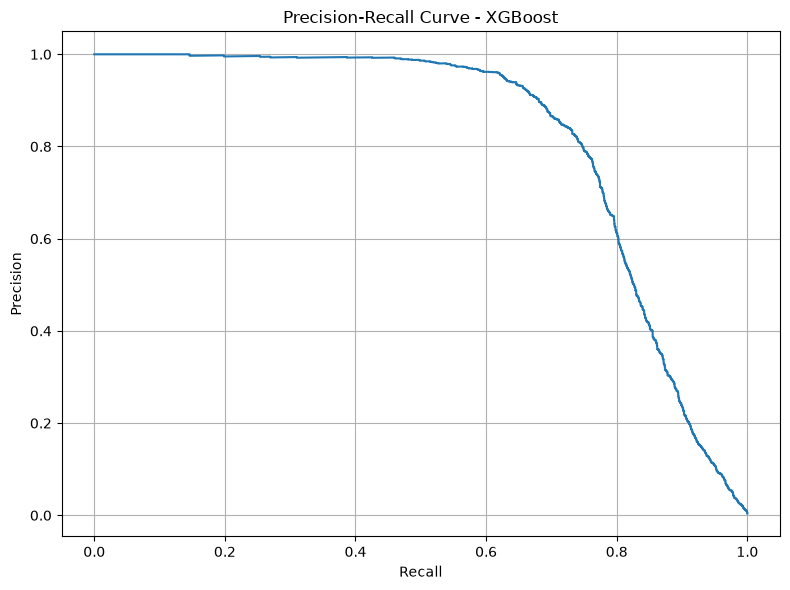

In [10]:
# ============================================================
# CELL 8: MODEL COMPARISON + FINAL TEST
# ============================================================

# ============================================================
# VALIDATION COMPARISON
# ============================================================

comparison_results = []

for model_name in model_probabilities:

    probabilities = (
        model_probabilities[
            model_name
        ]
    )

    threshold = (
        model_thresholds[
            model_name
        ]
    )

    result = validation_metrics(

        model_name,

        y_val,

        probabilities,

        threshold
    )

    comparison_results.append(
        result
    )


comparison = pd.DataFrame(
    comparison_results
)

comparison = comparison.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)


print("=" * 90)
print("VALIDATION MODEL COMPARISON")
print("=" * 90)

print(
    comparison.to_string(
        index=False
    )
)


# ============================================================
# SELECT BEST MODEL BASED ON VALIDATION PR-AUC
# ============================================================

best_model_name = comparison.iloc[
    0
]["Model"]

selected_threshold = (
    model_thresholds[
        best_model_name
    ]
)

print("\n" + "=" * 90)

print(
    "SELECTED MODEL:",
    best_model_name
)

print(
    "SELECTED THRESHOLD:",
    selected_threshold
)

print("=" * 90)


# ============================================================
# TEST PREDICTIONS
# ============================================================

if best_model_name == "Logistic Regression":

    test_prob = lr_model.predict_proba(
        X_test_scaled
    )[:, 1]


elif best_model_name == "Random Forest":

    test_prob = rf_model.predict_proba(
        X_test_encoded
    )[:, 1]


elif best_model_name == "XGBoost":

    test_prob = xgb_model.predict_proba(
        X_test_encoded
    )[:, 1]


elif best_model_name == "LightGBM":

    test_prob = lgb_model.predict_proba(
        X_test
    )[:, 1]


elif best_model_name == "CatBoost":

    test_prob = cat_model.predict_proba(
        X_test_cb
    )[:, 1]


elif best_model_name == "Neural Network":

    test_prob = nn_model.predict(
        X_test_scaled,
        batch_size=8192,
        verbose=0
    ).ravel()


# ============================================================
# FINAL PREDICTIONS
# ============================================================

test_predictions = (
    test_prob >= selected_threshold
).astype(int)


# ============================================================
# FINAL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_prob
)

pr_auc = average_precision_score(
    y_test,
    test_prob
)


print("\n" + "=" * 90)
print("FINAL TEST RESULTS")
print("=" * 90)

print(
    f"Model        : {best_model_name}"
)

print(
    f"Threshold    : {selected_threshold:.2f}"
)

print(
    f"Accuracy     : {accuracy:.4f}"
)

print(
    f"Precision    : {precision:.4f}"
)

print(
    f"Recall       : {recall:.4f}"
)

print(
    f"F1           : {f1:.4f}"
)

print(
    f"ROC-AUC      : {roc_auc:.4f}"
)

print(
    f"PR-AUC       : {pr_auc:.4f}"
)

print(
    f"Fraud Alerts : {test_predictions.sum()}"
)

print(
    f"Actual Fraud : {y_test.sum()}"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_predictions
)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Not Fraud",
            "Fraud"
        ],
        zero_division=0
    )
)


# ============================================================
# MODEL COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison["Model"],
    comparison["PR-AUC"]
)

plt.ylabel(
    "Validation PR-AUC"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Fraud Detection Model Comparison"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_prob
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    f"Precision-Recall Curve - {best_model_name}"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [11]:
# ============================================================
# SELECT BEST MODEL + BEST THRESHOLD
# ============================================================

# Make sure these contain the validation PR-AUC of each model.
# Adjust the dictionary names if your previous comparison cell
# uses different variable names.

model_results = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model,
    "Neural Network": nn_model
}

# ------------------------------------------------------------
# Get validation probabilities
# ------------------------------------------------------------

validation_probabilities = {}

validation_probabilities["Logistic Regression"] = (
    lr_model.predict_proba(X_val_scaled)[:, 1]
)

validation_probabilities["Random Forest"] = (
    rf_model.predict_proba(X_val_encoded)[:, 1]
)

validation_probabilities["XGBoost"] = (
    xgb_model.predict_proba(X_val_encoded)[:, 1]
)

validation_probabilities["LightGBM"] = (
    lgb_model.predict_proba(X_val)[:, 1]
)

validation_probabilities["CatBoost"] = (
    cat_model.predict_proba(X_val_cb)[:, 1]
)

validation_probabilities["Neural Network"] = (
    nn_model.predict(
        X_val_scaled,
        verbose=0
    ).reshape(-1)
)


# ============================================================
# FIND BEST THRESHOLD FOR EACH MODEL
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    f1_score
)

thresholds = np.arange(
    0.01,
    0.96,
    0.01
)

model_summary = []

best_thresholds = {}

for name, probabilities in validation_probabilities.items():

    # Validation PR-AUC
    pr_auc = average_precision_score(
        y_val,
        probabilities
    )

    # Find threshold giving maximum F1
    best_f1 = -1
    best_thr = 0.5

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        f1 = f1_score(
            y_val,
            predictions,
            zero_division=0
        )

        if f1 > best_f1:

            best_f1 = f1
            best_thr = threshold

    best_thresholds[name] = best_thr

    model_summary.append({
        "Model": name,
        "Validation PR-AUC": pr_auc,
        "Best Threshold": best_thr,
        "Validation F1": best_f1
    })


# ============================================================
# COMPARE MODELS
# ============================================================

comparison = pd.DataFrame(
    model_summary
).sort_values(
    "Validation PR-AUC",
    ascending=False
)

print("\nValidation results:")
display(comparison)


# ============================================================
# SELECT BEST MODEL USING VALIDATION PR-AUC
# ============================================================

best_model_name = comparison.iloc[0]["Model"]

best_threshold = best_thresholds[
    best_model_name
]

best_model = model_results[
    best_model_name
]


print("\n" + "=" * 60)
print("SELECTED MODEL")
print("=" * 60)

print(f"Model     : {best_model_name}")
print(f"PR-AUC    : {comparison.iloc[0]['Validation PR-AUC']:.4f}")
print(f"F1        : {comparison.iloc[0]['Validation F1']:.4f}")
print(f"Threshold : {best_threshold:.2f}")

print("=" * 60)


Validation results:


,Model,Validation PR-AUC,Best Threshold,Validation F1
2,XGBoost,0.867230,0.66,0.809694
4,CatBoost,0.843986,0.91,0.789120
1,Random Forest,0.799499,0.51,0.766190
3,LightGBM,0.797452,0.19,0.762585
5,Neural Network,0.729702,0.95,0.677347
0,Logistic Regression,0.249981,0.95,0.421998



SELECTED MODEL
Model     : XGBoost
PR-AUC    : 0.8672
F1        : 0.8097
Threshold : 0.66


In [12]:
# ============================================================
# SAVE COMPLETE FRAUD DETECTION PIPELINE
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

SAVE_DIR = "saved_fraud_model"
os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 70)
print("SAVING COMPLETE FRAUD DETECTION PIPELINE")
print("=" * 70)


# ------------------------------------------------------------
# 1. IDENTIFY BEST MODEL
# ------------------------------------------------------------

print(f"\nBest model: {best_model_name}")
print(f"Best threshold: {best_threshold:.4f}")


# ------------------------------------------------------------
# 2. SAVE FEATURE INFORMATION
# ------------------------------------------------------------

# These are the columns used by the models after preprocessing.
feature_columns = X_train.columns.tolist()

# For models such as Logistic Regression / RF / XGBoost / NN
# this is the numerical encoded feature set.
encoded_feature_columns = X_train_encoded.columns.tolist()


# ------------------------------------------------------------
# 3. SAVE CATEGORICAL INFORMATION
# ------------------------------------------------------------

category_mappings = {}
category_categories = {}

for col in categorical_features:

    # X_train[col] should be a pandas categorical column
    categories = X_train[col].cat.categories.tolist()

    category_categories[col] = categories

    # Mapping from original category -> integer
    category_mappings[col] = {
        str(category): int(i)
        for i, category in enumerate(categories)
    }


# ------------------------------------------------------------
# 4. SAVE TRAINING MEDIANS
# ------------------------------------------------------------

# These are the medians calculated from the training set.
# They MUST NOT be recalculated on future prediction data.

train_medians_to_save = train_medians.copy()


# ------------------------------------------------------------
# 5. SAVE SCALER
# ------------------------------------------------------------

# For LR / NN this is important.
# For tree models it may not be used, but saving it makes
# the bundle complete.

scaler_to_save = scaler


# ------------------------------------------------------------
# 6. SAVE CARD BEHAVIOR STATISTICS
# ------------------------------------------------------------

# These were calculated from the training data.
card_stats_to_save = card_stats.copy()


# ------------------------------------------------------------
# 7. SAVE MERCHANT FREQUENCY
# ------------------------------------------------------------

merchant_frequency_to_save = merchant_frequency.copy()


# ------------------------------------------------------------
# 8. SAVE CITY FREQUENCY
# ------------------------------------------------------------

city_frequency_to_save = city_frequency.copy()


# ------------------------------------------------------------
# 9. SAVE PREPROCESSING BUNDLE
# ------------------------------------------------------------

preprocessing_bundle = {

    # Feature information
    "feature_columns": feature_columns,
    "encoded_feature_columns": encoded_feature_columns,

    # Categorical information
    "categorical_features": categorical_features,
    "category_mappings": category_mappings,
    "category_categories": category_categories,

    # Training-dependent preprocessing
    "train_medians": train_medians_to_save,
    "scaler": scaler_to_save,

    # Behavioral features
    "card_stats": card_stats_to_save,
    "merchant_frequency": merchant_frequency_to_save,
    "city_frequency": city_frequency_to_save,

    # Classification threshold
    "threshold": float(best_threshold),

    # Pipeline version
    "pipeline_version": "1.0"
}


joblib.dump(
    preprocessing_bundle,
    os.path.join(SAVE_DIR, "preprocessing.pkl")
)

print("\n✓ preprocessing.pkl saved")


# ------------------------------------------------------------
# 10. SAVE MODEL
# ------------------------------------------------------------

model_filename = None

if best_model_name == "Logistic Regression":

    model_filename = "model.joblib"

    joblib.dump(
        best_model,
        os.path.join(SAVE_DIR, model_filename)
    )


elif best_model_name == "Random Forest":

    model_filename = "model.joblib"

    joblib.dump(
        best_model,
        os.path.join(SAVE_DIR, model_filename)
    )


elif best_model_name == "XGBoost":

    model_filename = "model.xgb.json"

    best_model.save_model(
        os.path.join(SAVE_DIR, model_filename)
    )


elif best_model_name == "LightGBM":

    model_filename = "model.lgb.txt"

    best_model.booster_.save_model(
        os.path.join(SAVE_DIR, model_filename)
    )


elif best_model_name == "CatBoost":

    model_filename = "model.cbm"

    best_model.save_model(
        os.path.join(SAVE_DIR, model_filename)
    )


elif best_model_name == "Neural Network":

    model_filename = "model.keras"

    best_model.save(
        os.path.join(SAVE_DIR, model_filename)
    )


else:
    raise ValueError(
        f"Unknown model type: {best_model_name}"
    )


print(f"✓ {model_filename} saved")


# ------------------------------------------------------------
# 11. SAVE METADATA
# ------------------------------------------------------------

metadata = {

    "model_name": best_model_name,

    "model_file": model_filename,

    "threshold": float(best_threshold),

    "categorical_features": categorical_features,

    "feature_columns": feature_columns,

    "encoded_feature_columns": encoded_feature_columns,

    "pipeline_version": "1.0"

}

with open(
    os.path.join(SAVE_DIR, "metadata.json"),
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


print("✓ metadata.json saved")


# ------------------------------------------------------------
# 12. SHOW SAVED FILES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAVED FILES")
print("=" * 70)

for file in os.listdir(SAVE_DIR):

    path = os.path.join(SAVE_DIR, file)

    size_mb = os.path.getsize(path) / (1024 ** 2)

    print(f"{file:<30} {size_mb:>10.2f} MB")


print("\n✓ COMPLETE PIPELINE SAVED")
print("=" * 70)

SAVING COMPLETE FRAUD DETECTION PIPELINE

Best model: XGBoost
Best threshold: 0.6600

✓ preprocessing.pkl saved
✓ model.xgb.json saved
✓ metadata.json saved

SAVED FILES
metadata.json                        0.00 MB
model.xgb.json                      10.23 MB
preprocessing.pkl                    0.19 MB

✓ COMPLETE PIPELINE SAVED


In [13]:
# ============================================================
# LOAD SAVED FRAUD MODEL AND PREDICT
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# LOAD SAVED PIPELINE
# ------------------------------------------------------------

SAVE_DIR = "saved_fraud_model"


with open(
    os.path.join(SAVE_DIR, "metadata.json"),
    "r"
) as f:

    metadata = json.load(f)


preprocessing = joblib.load(
    os.path.join(SAVE_DIR, "preprocessing.pkl")
)


model_name = metadata["model_name"]
model_file = metadata["model_file"]
threshold = preprocessing["threshold"]

categorical_features = preprocessing["categorical_features"]

category_mappings = preprocessing["category_mappings"]
category_categories = preprocessing["category_categories"]

card_stats = preprocessing["card_stats"]
merchant_frequency = preprocessing["merchant_frequency"]
city_frequency = preprocessing["city_frequency"]

train_medians = preprocessing["train_medians"]
scaler = preprocessing["scaler"]

feature_columns = preprocessing["feature_columns"]
encoded_feature_columns = preprocessing["encoded_feature_columns"]


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model_path = os.path.join(
    SAVE_DIR,
    model_file
)


if model_name == "Logistic Regression":

    model = joblib.load(model_path)


elif model_name == "Random Forest":

    model = joblib.load(model_path)


elif model_name == "XGBoost":

    from xgboost import XGBClassifier

    model = XGBClassifier()

    model.load_model(model_path)


elif model_name == "LightGBM":

    import lightgbm as lgb

    booster = lgb.Booster(
        model_file=model_path
    )


elif model_name == "CatBoost":

    from catboost import CatBoostClassifier

    model = CatBoostClassifier()

    model.load_model(model_path)


elif model_name == "Neural Network":

    from tensorflow import keras

    model = keras.models.load_model(
        model_path
    )


else:

    raise ValueError(
        f"Unknown model type: {model_name}"
    )


print(f"Loaded model: {model_name}")
print(f"Fraud threshold: {threshold:.4f}")


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(
        np.sqrt(a)
    )

    return 6371 * c


def basic_features(df):

    df = df.copy()

    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"]
    )

    df["trans_hour"] = (
        df["trans_date_trans_time"].dt.hour
    )

    df["trans_day"] = (
        df["trans_date_trans_time"].dt.day
    )

    df["trans_month"] = (
        df["trans_date_trans_time"].dt.month
    )

    df["trans_dayofweek"] = (
        df["trans_date_trans_time"].dt.dayofweek
    )

    df["trans_dayofyear"] = (
        df["trans_date_trans_time"].dt.dayofyear
    )

    df["is_weekend"] = (
        df["trans_dayofweek"] >= 5
    ).astype("int8")

    df["is_night"] = (
        (df["trans_hour"] < 6)
        |
        (df["trans_hour"] >= 22)
    ).astype("int8")

    df["dob"] = pd.to_datetime(
        df["dob"]
    )

    df["customer_age"] = (
        df["trans_date_trans_time"]
        - df["dob"]
    ).dt.days / 365.25

    df["distance_km"] = haversine_distance(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

    df["log_amount"] = np.log1p(
        df["amt"]
    )

    return df


# ============================================================
# APPLY BEHAVIORAL FEATURES
# ============================================================

def apply_behavior_features(df):

    df = df.copy()

    # Card statistics learned during training
    df = df.join(
        card_stats,
        on="cc_num"
    )

    # Merchant frequency learned during training
    df["merchant_frequency"] = (
        df["merchant"]
        .map(merchant_frequency)
        .fillna(0)
    )

    # City frequency learned during training
    df["city_frequency"] = (
        df["city"]
        .map(city_frequency)
        .fillna(0)
    )

    # Remove columns that aren't model inputs
    drop_cols = [
        "is_fraud",
        "trans_num",
        "trans_date_trans_time",
        "dob",
        "first",
        "last",
        "street",
        "cc_num"
    ]

    drop_cols = [
        c for c in drop_cols
        if c in df.columns
    ]

    df = df.drop(
        columns=drop_cols
    )

    return df


# ============================================================
# PREPARE NEW DATA
# ============================================================

def prepare_prediction_data(df):

    # ----------------------------------------
    # Feature engineering
    # ----------------------------------------

    df = basic_features(df)

    # ----------------------------------------
    # Behavioral features
    # ----------------------------------------

    df = apply_behavior_features(df)

    # ----------------------------------------
    # Clean column names
    # ----------------------------------------

    df.columns = [
        str(c)
        .replace("[", "_")
        .replace("]", "_")
        .replace("<", "_")
        .replace(">", "_")
    ]

    # ----------------------------------------
    # Make sure all expected columns exist
    # ----------------------------------------

    for col in feature_columns:

        if col not in df.columns:

            df[col] = np.nan

    # Remove unexpected columns
    df = df[
        feature_columns
    ].copy()

    # ----------------------------------------
    # Categorical columns
    # ----------------------------------------

    for col in categorical_features:

        if col in df.columns:

            df[col] = (
                df[col]
                .astype(str)
            )

    # ----------------------------------------
    # Handle categorical columns
    # ----------------------------------------

    if model_name in [
        "LightGBM",
        "CatBoost"
    ]:

        # Keep the original categories
        # for these models

        for col in categorical_features:

            categories = (
                category_categories[col]
            )

            df[col] = pd.Categorical(
                df[col],
                categories=categories
            )

    else:

        # Numerical encoding for:
        # Logistic Regression
        # Random Forest
        # XGBoost
        # Neural Network

        for col in categorical_features:

            mapping = (
                category_mappings[col]
            )

            df[col] = (
                df[col]
                .map(mapping)
                .fillna(-1)
            )

    # ----------------------------------------
    # Convert numerical columns
    # ----------------------------------------

    for col in df.columns:

        if col not in categorical_features:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    # ----------------------------------------
    # Replace inf
    # ----------------------------------------

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # ----------------------------------------
    # Fill missing values
    # ----------------------------------------

    for col in df.columns:

        if col in categorical_features:
            continue

        if col in train_medians.index:

            df[col] = df[col].fillna(
                train_medians[col]
            )

        else:

            df[col] = df[col].fillna(0)

    return df


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_fraud(df):

    original_df = df.copy()

    # Prepare exactly like training
    X = prepare_prediction_data(df)

    # --------------------------------------------------------
    # LIGHTGBM
    # --------------------------------------------------------

    if model_name == "LightGBM":

        probabilities = booster.predict(
            X
        )

    # --------------------------------------------------------
    # CATBOOST
    # --------------------------------------------------------

    elif model_name == "CatBoost":

        probabilities = model.predict_proba(
            X
        )[:, 1]

    # --------------------------------------------------------
    # NEURAL NETWORK
    # --------------------------------------------------------

    elif model_name == "Neural Network":

        X_encoded = X.copy()

        # Ensure exact feature order
        X_encoded = X_encoded[
            encoded_feature_columns
        ]

        X_scaled = scaler.transform(
            X_encoded
        )

        probabilities = model.predict(
            X_scaled,
            verbose=0
        ).reshape(-1)

    # --------------------------------------------------------
    # LOGISTIC / RF / XGBOOST
    # --------------------------------------------------------

    else:

        X_encoded = X.copy()

        X_encoded = X_encoded[
            encoded_feature_columns
        ]

        if model_name == "Logistic Regression":

            X_scaled = scaler.transform(
                X_encoded
            )

            probabilities = model.predict_proba(
                X_scaled
            )[:, 1]

        else:

            probabilities = model.predict_proba(
                X_encoded
            )[:, 1]

    # --------------------------------------------------------
    # APPLY SAVED THRESHOLD
    # --------------------------------------------------------

    predictions = (
        probabilities >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    result = original_df.copy()

    result["fraud_probability"] = probabilities

    result["fraud_prediction"] = predictions

    result["fraud_label"] = np.where(
        predictions == 1,
        "FRAUD",
        "NOT FRAUD"
    )

    return result

Loaded model: XGBoost
Fraud threshold: 0.6600


In [14]:
import os
import joblib
import numpy as np
import pandas as pd
from xgboost import XGBClassifier


# ============================================================
# LOAD MODEL
# ============================================================

MODEL_PATH = "saved_fraud_model/model.xgb.json"
PREPROCESSING_PATH = "saved_fraud_model/preprocessing.pkl"

prep = joblib.load(PREPROCESSING_PATH)

model = XGBClassifier()
model.load_model(MODEL_PATH)


# ============================================================
# LOAD SAVED PREPROCESSING
# ============================================================

card_stats = prep["card_stats"]
merchant_frequency = prep["merchant_frequency"]
city_frequency = prep["city_frequency"]

categorical_features = prep["categorical_features"]
category_mappings = prep["category_mappings"]

train_medians = prep["train_medians"]

feature_columns = prep["feature_columns"]
encoded_feature_columns = prep["encoded_feature_columns"]

threshold = prep["threshold"]


# ============================================================
# HAVERSINE DISTANCE
# ============================================================

def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(
        np.sqrt(a)
    )

    return 6371 * c


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(dataframe):

    dataframe = dataframe.copy()

    # Date
    dataframe["trans_date_trans_time"] = pd.to_datetime(
        dataframe["trans_date_trans_time"]
    )

    dataframe["trans_hour"] = (
        dataframe["trans_date_trans_time"].dt.hour
    )

    dataframe["trans_day"] = (
        dataframe["trans_date_trans_time"].dt.day
    )

    dataframe["trans_month"] = (
        dataframe["trans_date_trans_time"].dt.month
    )

    dataframe["trans_dayofweek"] = (
        dataframe["trans_date_trans_time"].dt.dayofweek
    )

    dataframe["trans_dayofyear"] = (
        dataframe["trans_date_trans_time"].dt.dayofyear
    )

    dataframe["is_weekend"] = (
        dataframe["trans_dayofweek"] >= 5
    ).astype("int8")

    dataframe["is_night"] = (
        (dataframe["trans_hour"] < 6)
        |
        (dataframe["trans_hour"] >= 22)
    ).astype("int8")

    # Age
    dataframe["dob"] = pd.to_datetime(
        dataframe["dob"]
    )

    dataframe["customer_age"] = (
        dataframe["trans_date_trans_time"]
        - dataframe["dob"]
    ).dt.days / 365.25

    # Distance
    dataframe["distance_km"] = haversine_distance(
        dataframe["lat"],
        dataframe["long"],
        dataframe["merch_lat"],
        dataframe["merch_long"]
    )

    # Log amount
    dataframe["log_amount"] = np.log1p(
        dataframe["amt"]
    )

    return dataframe


# ============================================================
# BEHAVIOR FEATURES
# ============================================================

def apply_behavior_features(dataframe):

    dataframe = dataframe.copy()

    # Card statistics
    dataframe = dataframe.join(
        card_stats,
        on="cc_num"
    )

    # Merchant frequency
    dataframe["merchant_frequency"] = (
        dataframe["merchant"]
        .map(merchant_frequency)
        .fillna(0)
    )

    # City frequency
    dataframe["city_frequency"] = (
        dataframe["city"]
        .map(city_frequency)
        .fillna(0)
    )

    # Remove columns not used by model
    columns_to_drop = [
        "is_fraud",
        "trans_num",
        "trans_date_trans_time",
        "dob",
        "first",
        "last",
        "street",
        "cc_num"
    ]

    dataframe = dataframe.drop(
        columns=[
            column
            for column in columns_to_drop
            if column in dataframe.columns
        ]
    )

    return dataframe


# ============================================================
# PREPARE DATA
# ============================================================

def prepare_data(dataframe):

    dataframe = create_features(dataframe)

    dataframe = apply_behavior_features(dataframe)

    # --------------------------------------------------------
    # Clean feature names
    # --------------------------------------------------------

    cleaned_columns = []

    for column in dataframe.columns:

        column = str(column)

        column = column.replace("[", "_")
        column = column.replace("]", "_")
        column = column.replace("<", "_")
        column = column.replace(">", "_")

        cleaned_columns.append(column)

    dataframe.columns = cleaned_columns

    # --------------------------------------------------------
    # Make sure all training features exist
    # --------------------------------------------------------

    for column in feature_columns:

        if column not in dataframe.columns:

            dataframe[column] = np.nan

    # --------------------------------------------------------
    # Keep only training features
    # --------------------------------------------------------

    dataframe = dataframe[
        feature_columns
    ].copy()

    # --------------------------------------------------------
    # Encode categorical features
    # --------------------------------------------------------

    for column in categorical_features:

        mapping = category_mappings[column]

        dataframe[column] = (
            dataframe[column]
            .astype(str)
            .map(mapping)
            .fillna(-1)
        )

    # --------------------------------------------------------
    # Convert everything to numeric
    # --------------------------------------------------------

    for column in dataframe.columns:

        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Replace infinity
    # --------------------------------------------------------

    dataframe = dataframe.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # --------------------------------------------------------
    # Fill missing values
    # --------------------------------------------------------

    for column in dataframe.columns:

        if column in train_medians.index:

            dataframe[column] = (
                dataframe[column]
                .fillna(train_medians[column])
            )

        else:

            dataframe[column] = (
                dataframe[column]
                .fillna(0)
            )

    # --------------------------------------------------------
    # Exact training feature order
    # --------------------------------------------------------

    dataframe = dataframe[
        encoded_feature_columns
    ]

    return dataframe


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_fraud(data):

    """
    Input:
        data: Python dictionary containing one transaction.

    Output:
        Dictionary containing fraud probability,
        prediction and label.
    """

    # Convert JSON/dictionary to DataFrame
    dataframe = pd.DataFrame([data])

    # Apply preprocessing
    prepared_data = prepare_data(
        dataframe
    )

    # Fraud probability
    probability = float(
        model.predict_proba(
            prepared_data
        )[0, 1]
    )

    # Apply saved threshold
    prediction = int(
        probability >= threshold
    )

    # Label
    if prediction == 1:
        label = "FRAUD"
    else:
        label = "NOT FRAUD"

    # Return JSON-compatible dictionary
    return {
        "fraud_probability": round(
            probability,
            6
        ),
        "fraud_prediction": prediction,
        "fraud_label": label
    }

In [15]:
transaction = {
    "trans_date_trans_time": "2019-01-01 00:00:00",
    "cc_num": 1234567890123456,
    "merchant": "fraud_Rippin, Kub and Mann",
    "category": "misc_net",
    "amt": 100.5,
    "first": "John",
    "last": "Doe",
    "gender": "M",
    "street": "123 Main St",
    "city": "New York",
    "state": "NY",
    "zip": 10001,
    "lat": 40.7128,
    "long": -74.0060,
    "city_pop": 100000,
    "job": "Engineer",
    "dob": "1985-01-01",
    "trans_num": "abc123",
    "unix_time": 1546300800,
    "merch_lat": 40.7130,
    "merch_long": -74.0050
}

result = predict_fraud(transaction)

print(result)

{'fraud_probability': 8e-06, 'fraud_prediction': 0, 'fraud_label': 'NOT FRAUD'}


In [16]:
# Get an actual fraud transaction
fraud_row = test_df[
    test_df["is_fraud"] == 1
].iloc[0]

# Save the actual class separately
actual_class = int(fraud_row["is_fraud"])

# Convert transaction to dictionary
fraud_transaction = fraud_row.drop(
    "is_fraud"
).to_dict()

# Predict
result = predict_fraud(fraud_transaction)

print("Actual class:", actual_class)
print("Model result:", result)

Actual class: 1
Model result: {'fraud_probability': 0.00162, 'fraud_prediction': 0, 'fraud_label': 'NOT FRAUD'}


In [17]:
import sklearn

print(sklearn.__version__)


1.9.1
